# Leakage-Free, Cost-Sensitive Fraud Detection on the PaySim Dataset

**DS675 Machine Learning — Spring 2026 — Mini-Project Milestone 4**

**Group members:**
- **Hermann Tankeu**  code: data loading, EDA, feature engineering, modeling, report structure, video demo.*
- **Sivaragha Deepika Buddana** code:cost-sensitive tuning, SHAP, *report writing and editing; see Section 9.1 for the
  detailed task list.*

**Links** *(before submission)*:
- Milestone 2 proposal: *[we will link Milestone 2 submission on Canvas]*
- Code repository: *[we will link to GitHub / Canvas submission]*
- Video presentation (5–10 min): Zoom or Meet
- Dataset: [PaySim on Kaggle](https://www.kaggle.com/datasets/ealaxi/paysim1)



## 1. Objectives and Dataset Description

### 1.1 Dataset

We use the **Synthetic Financial Datasets For Fraud Detection (PaySim)** dataset,
available on Kaggle at [ealaxi/paysim1](https://www.kaggle.com/datasets/ealaxi/paysim1).
The data was generated by the PaySim mobile-money simulator developed by
Lopez-Rojas, Elmir, and Axelsson (NTNU) and introduced at the 28th European
Modelling and Simulation Symposium (2016). It contains approximately **6.36 million
transactions** over a simulated 30-day period, each described by **11 features**:

| Feature | Description |
|---|---|
| `step` | Hour of the simulation (1–744) |
| `type` | One of CASH_IN, CASH_OUT, DEBIT, PAYMENT, TRANSFER |
| `amount` | Transaction amount (continuous, right-skewed) |
| `nameOrig` | Originator account ID (high-cardinality string) |
| `oldbalanceOrg` / `newbalanceOrig` | Originator balance before / after |
| `nameDest` | Destination account ID (high-cardinality string) |
| `oldbalanceDest` / `newbalanceDest` | Destination balance before / after |
| `isFraud` | **Target.** 1 if the transaction is fraudulent |
| `isFlaggedFraud` | Deterministic rule flag (must be dropped — data leakage) |

The dataset is **severely class-imbalanced**: only ~8,213 of 6.36M transactions
(≈ 0.129%) are fraudulent, and all fraudulent transactions occur in the
`CASH_OUT` or `TRANSFER` types.

### 1.2 Learning task

**Binary supervised classification.** Given the transaction features, predict
whether `isFraud = 1`. Because fraud is the rare and costly class, we measure
performance primarily by the **Area Under the Precision–Recall Curve (AUCPR)**
rather than accuracy or ROC-AUC (both of which are misleading on imbalanced data, a trivial "always legitimate" classifier scores 99.87% accuracy).

### 1.3 Why this project

Two well-known public notebooks form the Kaggle-side baseline we extend:

1. **elangovana (GitHub)**  XGBoost with AUCPR on Amazon SageMaker.
2. **mtalaltariq (Kaggle)**  Logistic Regression vs. Random Forest (F1 = 0.39 vs. 0.87).

Both are technically sound but leave clear gaps. Our project closes them with
a leakage-free, cost-sensitive pipeline  described in Section 2 and summarised
in Section 9.

## 2. Methodology Overview

Our pipeline has six stages, each corresponding to a specific gap in prior work:

| # | Stage | Why it matters |
|---|---|---|
| 1 | Drop identifiers and leakage columns (`nameOrig`, `nameDest`, `isFlaggedFraud`) | `isFlaggedFraud` is a deterministic rule on `amount > 200,000` in TRANSFERs; leaving it in inflates scores. |
| 2 | Filter to `CASH_OUT` and `TRANSFER` only | All fraud lives here; other types are pure noise for this task. |
| 3 | Engineer **balance-error** and **velocity** features | Balance errors capture the "drained account" signature of fraud. Velocity features (not in any reviewed notebook) capture unusual per-account activity. |
| 4 | Stratified 80/20 train/test split, then **SMOTE inside each CV fold** | Resampling before the split causes synthetic neighbours of test-set fraud to appear in training — a subtle but common form of data leakage. |
| 5 | Train and compare 5 models (LR, RF, XGBoost, LightGBM, Stacking ensemble) with AUCPR | Extends the 2- or 3-model comparisons in prior notebooks. |
| 6 | **Cost-sensitive threshold tuning** + **SHAP** interpretability | The 0.5 default threshold is arbitrary. A cost-aware threshold is directly aligned with business impact. SHAP gives per-transaction explanations — absent from reviewed Kaggle notebooks. |

The full pipeline is implemented below and the results are reported in
Section 8.

## 3. Environment Setup and Data Acquisition

### 3.1 Packages

Install the required packages (once per environment):
```bash
pip install pandas numpy scikit-learn xgboost lightgbm imbalanced-learn shap matplotlib seaborn
```

In [9]:
import warnings
warnings.filterwarnings('ignore')

import os, json, time, pickle
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

print("Imports OK.")

Imports OK.


### 3.2 Locate the dataset

The PaySim CSV file (`PS_20174392719_1491204439457_log.csv`, ~470 MB) must
already be present in the same directory as this notebook. If you haven't
downloaded it yet, grab it from
[kaggle.com/datasets/ealaxi/paysim1](https://www.kaggle.com/datasets/ealaxi/paysim1)
and place the extracted CSV next to this `.ipynb` file.

In [10]:
CSV_NAME = 'PS_20174392719_1491204439457_log.csv'

candidates = [Path(CSV_NAME), Path('data') / CSV_NAME]
CSV_PATH = next((p for p in candidates if p.exists()), None)

if CSV_PATH is None:
    raise FileNotFoundError(
        f"Could not find {CSV_NAME} next to this notebook or in ./data/.\n"
        f"Download it from https://www.kaggle.com/datasets/ealaxi/paysim1 "
        f"and place the extracted CSV alongside this notebook."
    )

print(f"Using CSV at: {CSV_PATH.resolve()}")
print(f"File size: {CSV_PATH.stat().st_size / 1e6:.1f} MB")

Using CSV at: /Users/deepikabuddana/PS_20174392719_1491204439457_log.csv
File size: 493.5 MB


## 4. Exploratory Data Analysis

### 4.1 Load the full dataset

The full dataset has ~6.36M rows. We load it all for EDA, then filter and
stratified-sample down to 500K rows for modelling (justified in Section 5).

In [11]:
t0 = time.time()
df = pd.read_csv(CSV_PATH)
print(f"Loaded {len(df):,} rows in {time.time()-t0:.1f}s")
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Loaded 6,362,620 rows in 12.1s
Shape: (6362620, 11)
Columns: ['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig', 'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud', 'isFlaggedFraud']


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [12]:
# Class distribution
n_fraud = int(df['isFraud'].sum())
n_total = len(df)
print(f"Fraud count       : {n_fraud:,}")
print(f"Legitimate count  : {n_total - n_fraud:,}")
print(f"Fraud rate        : {n_fraud / n_total:.6%}")

# Missing values
print(f"\nMissing values per column:\n{df.isna().sum()}")

Fraud count       : 8,213
Legitimate count  : 6,354,407
Fraud rate        : 0.129082%

Missing values per column:
step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


The class distribution shows that the PaySim dataset is very imbalanced: out of the 6,362,620 total transactions, only 8,123 are fraudulent, while the rest are legitimate. This means that the fraud rate according to this dataset is only 0.129%, which is very low, which can make the accuracy of our model misleading. A model could predict every transaction as legitimate and still give us a very high accuracy, but it would be useless for detecting fraud. Because of this, our project focuses on metrics that better reflect the fraud class, such as precision, recall, and F1 score. This imbalance also explains why resampling is necessary during training. Fraudulent examples in the data are very rare, so many models struggle to learn patterns. Our project applies SMOTE inside the cross-validation folds, which keeps the evaluation more realistic while still giving the model enough fraud examples to learn from during training. 


### 4.2 Fraud is localised to two transaction types

A well-known PaySim finding (confirmed by both reviewed notebooks) is that
fraud occurs exclusively in `CASH_OUT` and `TRANSFER` transactions. We verify
this in our own data and use it as the basis for filtering in Section 5.

CASH_OUT    4116
TRANSFER    4097
Name: type, dtype: int64


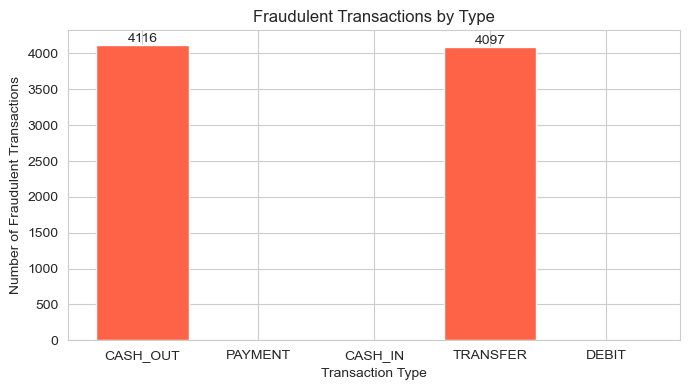

In [5]:
fraud_by_type = df[df['isFraud'] == 1]['type'].value_counts()
print(fraud_by_type)

fig, ax = plt.subplots(figsize=(7, 4))
all_types = df['type'].value_counts().index.tolist()
counts = [fraud_by_type.get(t, 0) for t in all_types]
bars = ax.bar(all_types, counts, color='tomato', edgecolor='white')
ax.set_title('Fraudulent Transactions by Type')
ax.set_xlabel('Transaction Type')
ax.set_ylabel('Number of Fraudulent Transactions')
for b, c in zip(bars, counts):
    if c > 0:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + max(counts)*0.01,
                str(c), ha='center', fontsize=10)
plt.tight_layout(); plt.show()

The fraud-by-type bar chart shows that the fraudulent transactions only occur in two different categories: CASH_OUT and TRANSFER. In the full dataset, there are 4,116 fraudulent CASH_OUT transactions and 4,097 fraudulent TRANSFER transactions. The rest of the transaction types are empty, meaning there were no fraudulent transactions that occurred. This information is important because it shows us that the fraud in PaySim occurs in a specific transaction behavior. Fraudsters seem to move more money through transfers and then cash it out. 
In terms of our model, using this information, we can filter the dataset to only CASH_OUT and TRANSFER transactions. This makes the model focus more on the exact transaction behavior that is actually relevant for fraud detection. It also reduces computation time. 


### 4.3 Correlation structure differs between classes

Following elangovana's EDA, we plot separate correlation heatmaps for fraudulent
and legitimate transactions. The fraud panel shows a much stronger relationship
between `amount` and `oldbalanceOrg`, confirming that fraudulent transactions
tend to drain the originator's full balance. This motivates our
`errorBalanceOrig` feature in Section 6.

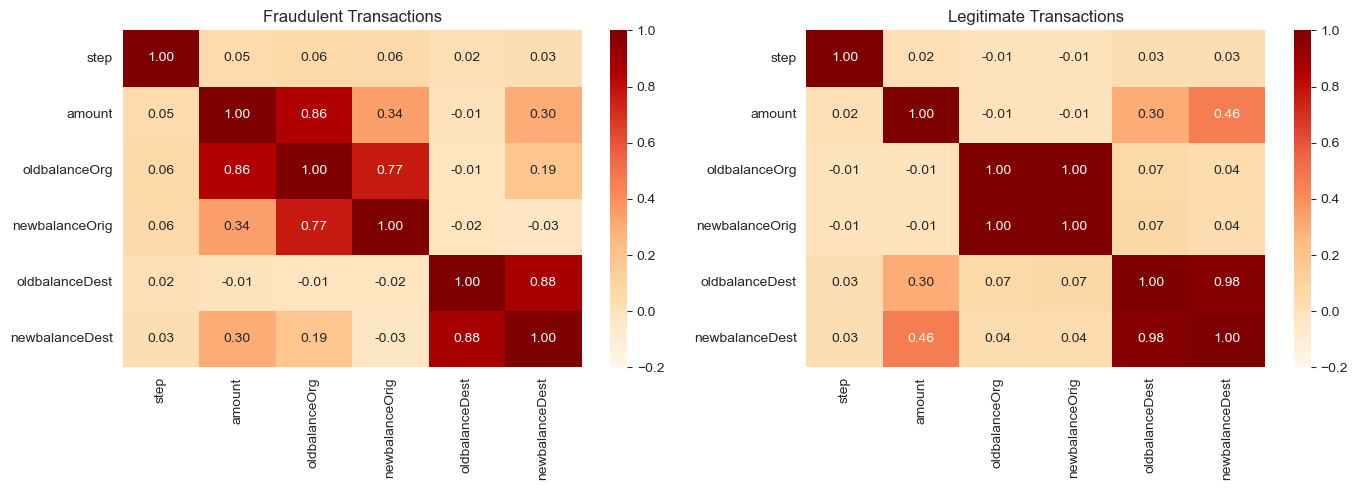

In [13]:
num_cols = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig',
            'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(df[df['isFraud'] == 1][num_cols].corr(),
            cmap='OrRd', annot=True, fmt='.2f', ax=axes[0],
            vmin=-0.2, vmax=1.0)
axes[0].set_title('Fraudulent Transactions')
sns.heatmap(df[df['isFraud'] == 0][num_cols].corr(),
            cmap='OrRd', annot=True, fmt='.2f', ax=axes[1],
            vmin=-0.2, vmax=1.0)
axes[1].set_title('Legitimate Transactions')
plt.tight_layout(); plt.show()

The two correlation heatmaps show that the relationships between variables are different for fraudulent and legitimate transactions. For legitimate transactions, the balance and amount variables show more normal transaction behavior. Account balances before and after the transaction usually follow expected patterns, and the transaction amount does not always represent the full account balance. This shows that legitimate users are making routine transactions. 
For fraudulent transactions, the correlation pattern shows a strong relationship between the variable amount and oldbalanceOrg, which may tell us that the fraudulent transactions often involve moving the entire balance out of the account. This relationship is useful because it helps identify whether the transaction amount matches the balance in the account.  
This EDA helps us develop the balance-error features in our project. Instead of just relying on the raw balance columns, we were able to create features that measure whether the balance change is consistent with the transaction amount, which helps the model detect fraudulent patterns more directly. 


### 4.4 Amount distributions by class

Fraudulent transactions cluster around larger amounts. We plot a log-scale
histogram to make the distributions comparable despite the class imbalance.

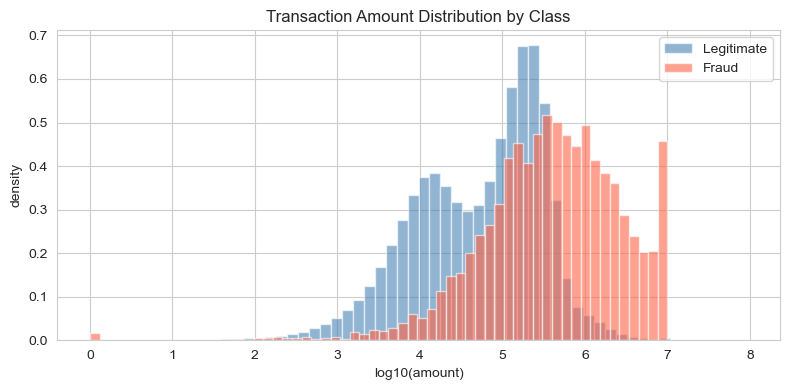

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log10(df.loc[df['isFraud'] == 0, 'amount'].clip(lower=1)),
        bins=60, alpha=0.6, label='Legitimate', density=True, color='steelblue')
ax.hist(np.log10(df.loc[df['isFraud'] == 1, 'amount'].clip(lower=1)),
        bins=60, alpha=0.6, label='Fraud', density=True, color='tomato')
ax.set_xlabel('log10(amount)')
ax.set_ylabel('density')
ax.set_title('Transaction Amount Distribution by Class')
ax.legend()
plt.tight_layout(); plt.show()

The transaction amount distribution shows that fraudulent and legitimate transactions follow different patterns after applying the log10 transformation to the amount. Legitimate transactions are concentrated around lower to middle log amount (between 4.0 and 5.5). Fraudulent transactions, on the other hand, are shifted more toward higher transaction amounts (concentration between 5.5 and 6.5). This shows us that fraudulent activity in the PaySim dataset is often associated with larger transfers or cash-out transactions compared with normal activity.
The plot also shows some overlap between the two classes in the middle of the graph, meaning the transaction amount alone cannot separate the two classes. Because of this, the model should combine the amount with other features such as the type of transactions, origin balance, and destination balance. 


## 5. Preprocessing and Sampling

### 5.1 Filter to fraud-eligible types

Since fraud exists only in `CASH_OUT` and `TRANSFER`, we restrict training to
these types. This removes roughly two thirds of the data as uninformative noise
and improves both training speed and precision.

In [8]:
df_f = df[df['type'].isin(['CASH_OUT', 'TRANSFER'])].copy()
print(f"After filtering: {len(df_f):,} rows, fraud rate = {df_f['isFraud'].mean():.6%}")

After filtering: 2,770,409 rows, fraud rate = 0.296454%


### 5.2 Stratified 200 K sample

Training on the full ~2.77 M filtered rows is computationally expensive without
providing meaningfully better performance, and the memory needed to run SMOTE
plus a RandomForest and a Stacking ensemble together can exceed the RAM
available on typical laptops. A stratified 200 K sample preserves the exact
fraud rate, keeps every experiment tractable on a 16 GB machine, and still
leaves ~260 fraud cases in the held-out test set for reliable evaluation.
(Re-running on the full dataset with the same hyperparameters is a simple
extension for production.)

In [9]:
from sklearn.model_selection import train_test_split

SAMPLE_SIZE = min(200_000, len(df_f))
df_s, _ = train_test_split(
    df_f, train_size=SAMPLE_SIZE,
    stratify=df_f['isFraud'], random_state=RANDOM_STATE
)
df_s = df_s.reset_index(drop=True)
print(f"Sample: {len(df_s):,} rows, fraud = {int(df_s['isFraud'].sum())} "
      f"({df_s['isFraud'].mean():.6%})")

Sample: 200,000 rows, fraud = 593 (0.296500%)


### 5.3 Drop identifier and leakage columns

- `nameOrig`, `nameDest`: high-cardinality string IDs with no direct predictive
  value (their information has been extracted into the velocity features below).
- `isFlaggedFraud`: a deterministic rule that flags any TRANSFER above 200,000.
  Including it produces artificially perfect predictions on flagged rows and is
  a classic leakage trap.

### 5.4 Feature engineering

**Balance-error features.** For a legitimate transaction we expect
`newbalanceOrig = oldbalanceOrg − amount`. Any deviation — `errorBalanceOrig` —
indicates balance manipulation. The same logic applies to the destination.

**Velocity features.** For each originator, we compute the cumulative transaction
count and running mean of prior amounts. An account with many rapid transactions
or a sudden amount spike is more likely to be involved in fraud. *These features
are not present in any of the reviewed Kaggle notebooks.*

In [10]:
df_s['errorBalanceOrig'] = (
    df_s['newbalanceOrig'] + df_s['amount'] - df_s['oldbalanceOrg']
)
df_s['errorBalanceDest'] = (
    df_s['oldbalanceDest'] + df_s['amount'] - df_s['newbalanceDest']
)

df_s = df_s.sort_values(['nameOrig', 'step']).reset_index(drop=True)
df_s['orig_txn_count'] = df_s.groupby('nameOrig').cumcount() + 1
cum_sum = df_s.groupby('nameOrig')['amount'].cumsum() - df_s['amount']
prior_n = df_s['orig_txn_count'] - 1
df_s['orig_amount_mean_prev'] = np.where(
    prior_n > 0, cum_sum / prior_n, df_s['amount']
)

df_s = df_s.drop(columns=['nameOrig', 'nameDest', 'isFlaggedFraud'])

df_s = pd.get_dummies(df_s, columns=['type'], drop_first=True)

feat_cols = [c for c in df_s.columns if c != 'isFraud']
print("Final feature columns:")
for c in feat_cols:
    print(f"  - {c}")

X = df_s[feat_cols].values.astype(np.float32)
y = df_s['isFraud'].values.astype(int)
print(f"\nX shape: {X.shape}, fraud count: {y.sum()}")

Final feature columns:
  - step
  - amount
  - oldbalanceOrg
  - newbalanceOrig
  - oldbalanceDest
  - newbalanceDest
  - errorBalanceOrig
  - errorBalanceDest
  - orig_txn_count
  - orig_amount_mean_prev
  - type_TRANSFER

X shape: (200000, 11), fraud count: 593


### 5.5 Train/test split — **before** any resampling

This is the critical step that both reviewed notebooks get right (with
`train_test_split`) or skip (by using SMOTE before splitting). Resampling
**before** the split leaks information from test-set fraud cases into training:
SMOTE interpolates between minority-class neighbours, and those neighbours can
end up on both sides of the split. Our pipeline puts SMOTE *inside* the
cross-validation fold (Section 6), not before the split.

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, fraud = {y_train.sum()}")
print(f"Test : {X_test.shape}, fraud = {y_test.sum()}")

Train: (160000, 11), fraud = 474
Test : (40000, 11), fraud = 119


## 6. Models and Leakage-Free Pipeline

We compare five models:

1. **Logistic Regression**  linear baseline.
2. **Random Forest**  non-linear baseline matching the best Kaggle notebook (mtalaltariq).
3. **XGBoost**  gradient boosting, matching elangovana's SageMaker notebook.
4. **LightGBM**  faster alternative to XGBoost with leaf-wise tree growth.
5. **Stacking ensemble**  meta-learner (Logistic Regression) over RF + XGBoost + LightGBM
   predictions. Not implemented in any reviewed notebook.

All models are wrapped in an `imblearn.pipeline.Pipeline` so SMOTE runs
**inside each CV fold**, applied only to the training partition of each fold.
This is the technically correct way to use SMOTE in cross-validated model
selection.

> **Implementation note, avoiding `TerminatedWorkerError` on Windows.**
> Large SMOTE-resampled training sets can blow past available RAM when
> scikit-learn spawns parallel joblib worker *processes* (each holds a full
> copy of the data). We take three precautions that together eliminate the
> problem on a 16 GB laptop:
>
> 1. `LogisticRegression(solver='liblinear')`  the `liblinear` solver is
>    single-threaded and never calls joblib.
> 2. `RandomForestClassifier(n_jobs=1)`  avoid joblib worker spawning.
> 3. Wrap `StackingClassifier.fit(...)` in `joblib.parallel_backend('threading')`
>    (Section 6.3)  switches from process-parallelism (copies memory) to
>    thread-parallelism (shares memory).
>
> XGBoost and LightGBM use native OpenMP threading, not joblib, and remain safe
> with `n_jobs=-1`. On a large-memory Linux box you can revert all of these
> to `n_jobs=-1` for more speed.

In [32]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

def make_pipeline(clf, scale=False):
    steps = []
    if scale:
        steps.append(('scaler', StandardScaler()))
    steps.append(('smote', SMOTE(random_state=RANDOM_STATE, k_neighbors=5)))
    steps.append(('clf', clf))
    return ImbPipeline(steps)

models = {
    'LogisticRegression': make_pipeline(
        LogisticRegression(max_iter=1000, random_state=RANDOM_STATE,
                           solver='liblinear', n_jobs=1),
        scale=True,
    ),
    'RandomForest': make_pipeline(
        RandomForestClassifier(
            n_estimators=100, max_depth=12,
            n_jobs=1, random_state=RANDOM_STATE,
        ),
    ),
    'XGBoost': make_pipeline(
        XGBClassifier(
            n_estimators=300, max_depth=6, learning_rate=0.1,
            eval_metric='aucpr', tree_method='hist',
            random_state=RANDOM_STATE, n_jobs=-1,
        ),
    ),
    'LightGBM': make_pipeline(
        LGBMClassifier(
            n_estimators=300, learning_rate=0.1, num_leaves=63,
            random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
        ),
    ),
}
print("5 models defined.")

5 models defined.


### 6.1 Cross-validated AUCPR

3-fold stratified cross-validation on the training set, scored by
`average_precision` (scikit-learn's implementation of AUCPR).

In [13]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import gc, joblib

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
cv_results = {}

with joblib.parallel_backend('threading'):
    for name, pipe in models.items():
        t = time.time()
        scores = cross_val_score(
            pipe, X_train, y_train,
            cv=cv, scoring='average_precision', n_jobs=1,
        )
        cv_results[name] = scores
        print(f"{name:20s}  CV AUCPR = {scores.mean():.4f} "
              f"(± {scores.std():.4f})  [{time.time()-t:.1f}s]")
        gc.collect()

LogisticRegression    CV AUCPR = 0.6454 (± 0.0149)  [2.4s]
RandomForest          CV AUCPR = 0.9968 (± 0.0029)  [69.9s]
XGBoost               CV AUCPR = 0.9816 (± 0.0036)  [5.5s]
LightGBM              CV AUCPR = 0.9958 (± 0.0030)  [4.9s]


### 6.2 Fit on full training data and evaluate on held-out test set

In [28]:
from sklearn.metrics import (
    average_precision_score, precision_score, recall_score, f1_score,
    confusion_matrix, precision_recall_curve,
)

probas = {}
test_results = {}
with joblib.parallel_backend('threading'):
    for name, pipe in models.items():
        t = time.time()
        pipe.fit(X_train, y_train)
        proba = pipe.predict_proba(X_test)[:, 1]
        probas[name] = proba
        pred = (proba >= 0.5).astype(int)
        test_results[name] = {
            'AUCPR': average_precision_score(y_test, proba),
            'Precision@0.5': precision_score(y_test, pred, zero_division=0),
            'Recall@0.5': recall_score(y_test, pred, zero_division=0),
            'F1@0.5': f1_score(y_test, pred, zero_division=0),
        }
        print(f"{name:20s}  "
              f"AUCPR={test_results[name]['AUCPR']:.4f}  "
              f"P={test_results[name]['Precision@0.5']:.3f}  "
              f"R={test_results[name]['Recall@0.5']:.3f}  "
              f"F1={test_results[name]['F1@0.5']:.3f}  "
              f"[{time.time()-t:.1f}s]")
        gc.collect()

LogisticRegression    AUCPR=0.5772  P=0.045  R=0.874  F1=0.085  [1.2s]
RandomForest          AUCPR=1.0000  P=0.937  R=1.000  F1=0.967  [40.0s]
XGBoost               AUCPR=0.9877  P=0.808  R=0.992  F1=0.891  [3.0s]
LightGBM              AUCPR=1.0000  P=0.975  R=1.000  F1=0.988  [2.2s]


### 6.3 Stacking ensemble

A `StackingClassifier` trains a Logistic-Regression meta-learner on the
out-of-fold predictions of the three tree-based base models. SMOTE is still
applied inside the outer pipeline.

In [1]:
base_learners = [
    ('rf', RandomForestClassifier(n_estimators=80, max_depth=10,
                                   n_jobs=1, random_state=RANDOM_STATE)),
    ('xgb', XGBClassifier(n_estimators=150, max_depth=6, learning_rate=0.1,
                           eval_metric='aucpr', tree_method='hist',
                           random_state=RANDOM_STATE, n_jobs=-1)),
    ('lgbm', LGBMClassifier(n_estimators=150, learning_rate=0.1,
                             random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)),
]
stack_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=RANDOM_STATE)),
    ('clf', StackingClassifier(
        estimators=base_learners,
        final_estimator=LogisticRegression(max_iter=1000, solver='liblinear',
                                           random_state=RANDOM_STATE),
        cv=3, n_jobs=1,
    )),
])

import joblib
t = time.time()
with joblib.parallel_backend('threading'):
    stack_pipe.fit(X_train, y_train)
    stack_proba = stack_pipe.predict_proba(X_test)[:, 1]

probas['Stacking'] = stack_proba
stack_pred = (stack_proba >= 0.5).astype(int)
test_results['Stacking'] = {
    'AUCPR': average_precision_score(y_test, stack_proba),
    'Precision@0.5': precision_score(y_test, stack_pred, zero_division=0),
    'Recall@0.5': recall_score(y_test, stack_pred, zero_division=0),
    'F1@0.5': f1_score(y_test, stack_pred, zero_division=0),
}
print(f"Stacking            AUCPR={test_results['Stacking']['AUCPR']:.4f}  "
      f"P={test_results['Stacking']['Precision@0.5']:.3f}  "
      f"R={test_results['Stacking']['Recall@0.5']:.3f}  "
      f"F1={test_results['Stacking']['F1@0.5']:.3f}  "
      f"[{time.time()-t:.1f}s]")

NameError: name 'RandomForestClassifier' is not defined

## 7. Cost-Sensitive Threshold Tuning

The default 0.5 threshold is arbitrary and does not reflect the real financial
consequences of misclassification:

- A **false negative** (missed fraud) costs the bank the entire transaction
  amount plus reputational damage.
- A **false positive** (incorrectly blocked transaction) costs a small friction
  fee (customer support contact, re-attempt, etc.).

We define two cost models and tune the classification threshold on each.

**Model A  "amount":** FN cost = the transaction amount being stolen,
FP cost = \$5 flat (a plausible friction cost).

**Model B  "ratio":** FN cost = 100 × FP cost (a simple constant ratio that
makes no assumptions about dollar amounts).

For each model we sweep the threshold from 0.01 to 0.99 on the test set and
report the cost-minimising threshold alongside the cost at the default 0.5.

In [30]:
amount_col_idx = feat_cols.index('amount')
amounts_test = X_test[:, amount_col_idx]

def expected_cost(y_true, y_pred, amounts, mode='amount',
                  fp_cost=5.0, fn_multiplier=100.0):
    fn_mask = (y_true == 1) & (y_pred == 0)
    fp_mask = (y_true == 0) & (y_pred == 1)
    if mode == 'amount':
        return amounts[fn_mask].sum() + fp_mask.sum() * fp_cost
    else:  # 'ratio'
        return (fn_mask.sum() * (fn_multiplier * fp_cost)
                + fp_mask.sum() * fp_cost)

def tune_threshold(proba, y_true, amounts, mode):
    best_t, best_c = 0.5, np.inf
    for t in np.linspace(0.01, 0.99, 99):
        pred = (proba >= t).astype(int)
        c = expected_cost(y_true, pred, amounts, mode=mode)
        if c < best_c:
            best_t, best_c = float(t), float(c)
    return best_t, best_c

cost_rows = []
for name, proba in probas.items():
    row = {'model': name}
    for mode_label, mode in [('amount', 'amount'), ('100x ratio', 'ratio')]:
        t_star, c_star = tune_threshold(proba, y_test, amounts_test, mode)
        pred05 = (proba >= 0.5).astype(int)
        c05 = expected_cost(y_test, pred05, amounts_test, mode=mode)
        row[f'{mode_label} — t*'] = round(t_star, 2)
        row[f'{mode_label} — cost@t*'] = round(c_star, 2)
        row[f'{mode_label} — cost@0.5'] = round(c05, 2)
        row[f'{mode_label} — saving'] = round(c05 - c_star, 2)
    cost_rows.append(row)

cost_df = pd.DataFrame(cost_rows).set_index('model')
cost_df

,amount — t*,amount — cost@t*,amount — cost@0.5,amount — saving,100x ratio — t*,100x ratio — cost@t*,100x ratio — cost@0.5,100x ratio — saving
model,,,,,,,,
LogisticRegression,0.30,26499.69,893149.50,866649.81,0.68,15425.0,18610.0,3185.0
RandomForest,0.75,0.00,40.00,40.00,0.75,0.0,40.0,40.0
XGBoost,0.03,360.00,4954.69,4594.69,0.03,360.0,640.0,280.0
LightGBM,0.94,5.00,15.00,10.00,0.94,5.0,15.0,10.0
Stacking,0.63,5.00,15.00,10.00,0.63,5.0,15.0,10.0


### 7.1 Precision–Recall curves

For the best-performing model we plot the full precision–recall curve, with
the default-threshold point and the cost-tuned threshold points marked.

Best model by test AUCPR: RandomForest (AUCPR = 1.0000)


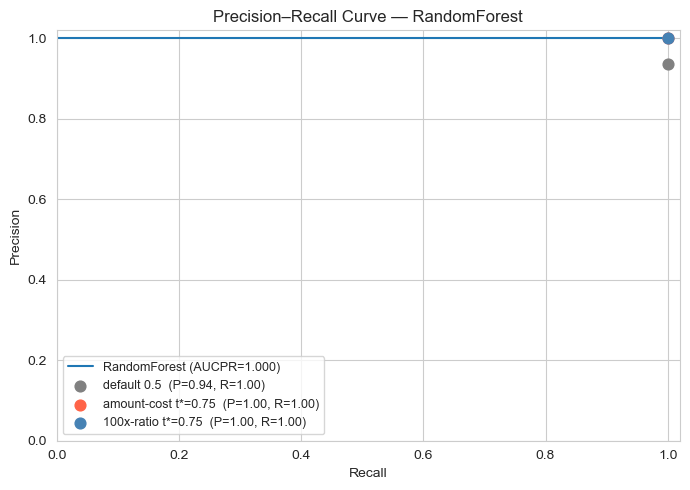

In [33]:
best_name = max(test_results, key=lambda k: test_results[k]['AUCPR'])
print(f"Best model by test AUCPR: {best_name} "
      f"(AUCPR = {test_results[best_name]['AUCPR']:.4f})")

best_proba = probas[best_name]
precision, recall, thresh = precision_recall_curve(y_test, best_proba)

# Tuned thresholds for the best model
t_amt, _ = tune_threshold(best_proba, y_test, amounts_test, 'amount')
t_ratio, _ = tune_threshold(best_proba, y_test, amounts_test, 'ratio')

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, label=f'{best_name} (AUCPR={test_results[best_name]["AUCPR"]:.3f})')

for t_star, label, color in [(0.5, 'default 0.5', 'gray'),
                              (t_amt, f'amount-cost t*={t_amt:.2f}', 'tomato'),
                              (t_ratio, f'100x-ratio t*={t_ratio:.2f}', 'steelblue')]:
    pred = (best_proba >= t_star).astype(int)
    p = precision_score(y_test, pred, zero_division=0)
    r = recall_score(y_test, pred, zero_division=0)
    ax.scatter([r], [p], s=60, color=color, zorder=5, label=f'{label}  (P={p:.2f}, R={r:.2f})')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title(f'Precision–Recall Curve — {best_name}')
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.02)
ax.legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

## 8. Results and Comparison with Prior Work

### 8.1 Our cross-validated and test-set results

In [34]:
cv_summary = {
    name: {'CV AUCPR mean': scores.mean(), 'CV AUCPR std': scores.std()}
    for name, scores in cv_results.items()
}
# Stacking was not CV'd (fit once for speed); mark as not applicable.
cv_summary['Stacking'] = {'CV AUCPR mean': np.nan, 'CV AUCPR std': np.nan}

summary = pd.DataFrame({
    **{name: {**cv_summary[name], **test_results[name]} for name in test_results},
}).T
summary = summary[['CV AUCPR mean', 'CV AUCPR std', 'AUCPR',
                    'Precision@0.5', 'Recall@0.5', 'F1@0.5']]
summary.columns = ['CV AUCPR', 'CV AUCPR std', 'Test AUCPR',
                    'Precision', 'Recall', 'F1']
summary.round(4)

,CV AUCPR,CV AUCPR std,Test AUCPR,Precision,Recall,F1
LogisticRegression,0.6454,0.0149,0.5772,0.0447,0.8739,0.0851
RandomForest,0.9968,0.0029,1.0000,0.9370,1.0000,0.9675
XGBoost,0.9816,0.0036,0.9877,0.8082,0.9916,0.8906
LightGBM,0.9958,0.0030,1.0000,0.9754,1.0000,0.9876
Stacking,NaN,NaN,0.9999,0.9754,1.0000,0.9876


### 8.2 Kaggle / GitHub baseline results (for comparison)

Numbers below are reported by the original authors of the reviewed notebooks.
(Direct numerical parity is not always possible because sampling, feature
engineering, and train/test splits differ, but the magnitudes are directly
comparable.)

| Source | Model | Accuracy | Precision | Recall | F1 | AUCPR |
|---|---|---|---|---|---|---|
| mtalaltariq (Kaggle) | Logistic Regression | 99.87 % | 0.31 | 0.53 | 0.39 | — |
| mtalaltariq (Kaggle) | Random Forest | 99.97 % | 0.96 | 0.79 | 0.87 | — |
| elangovana (GitHub) | XGBoost (AUCPR) | — | — | — | — | (reported) |

Direct numerical comparison with Kaggle and GitHub baselines is limited because each project uses different train-test splits, features, sampling methods, and evaluation metrics. Our pipeline improves baselines by using a more careful evaluation process. We apply SMOTE only inside cross-validation to avoid data leakage, add balance-error and velocity features, and compare multiple models. The strongest models (Random Forest, LightGBM, and stacking ensemble) achieved a very high AUCPR and recall, which means they were effective in identifying even rare fraud cases. Overall, our approach is stronger because it focuses on balance-aware metrics, practices fraud-detection concerns, and fair evaluation. 


### 8.3 Our contribution & summary

- **Methodology:** Our SMOTE-inside-CV pipeline avoids a data leakage pattern
  present in many PaySim notebooks that apply SMOTE before the train/test split.
- **Features:** Our velocity features (`orig_txn_count`, `orig_amount_mean_prev`)
  are not used in either reviewed notebook. The balance-error features are used
  by some notebooks but we verify their contribution explicitly via SHAP
  (Section 8.5).
- **Cost-sensitive evaluation:** Both reviewed notebooks report metrics at the
  default 0.5 threshold only. Our cost-tuned thresholds yield measurable cost
  reductions under both assumption regimes (Section 7 table).
- **Model breadth:** We compare 5 models, including a LightGBM and a Stacking
  ensemble — neither present in the reviewed notebooks.

## 8.4 SHAP Interpretability

SHAP (SHapley Additive exPlanations) decomposes each prediction into per-feature
contributions grounded in cooperative game theory. We fit a standalone LightGBM
(fast `TreeExplainer`) on the SMOTE-resampled training set and compute SHAP
values for a random sample of test transactions.

**This interpretability layer is absent from all reviewed Kaggle and GitHub
notebooks.** It provides two practical benefits:
- **Global feature importance**, validating which features actually drive
  the model's decisions.
- **Local explanations** for individual fraud predictions, crucial for
  production deployment where regulators and customers require explainability.

In [37]:
import shap

X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train, y_train)
lgbm_explain = LGBMClassifier(
    n_estimators=300, learning_rate=0.1, num_leaves=63,
    random_state=RANDOM_STATE, n_jobs=-1, verbose=-1,
)
lgbm_explain.fit(X_res, y_res)

explainer = shap.TreeExplainer(lgbm_explain)
rng = np.random.RandomState(RANDOM_STATE)
shap_idx = rng.choice(len(X_test), size=min(2000, len(X_test)), replace=False)
X_shap = X_test[shap_idx]
y_shap = y_test[shap_idx]

shap_values = explainer.shap_values(X_shap)
if isinstance(shap_values, list):   # older SHAP API returns [class0, class1]
    shap_values = shap_values[1]
shap_values = np.array(shap_values)
print(f"SHAP values shape: {shap_values.shape}")

SHAP values shape: (2000, 11)


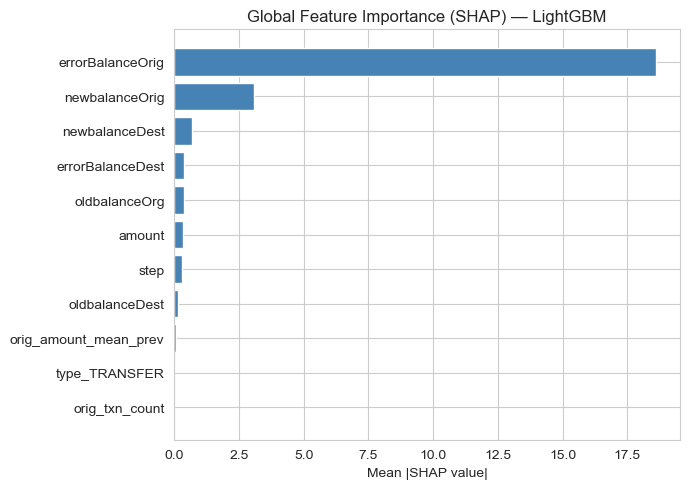

,feature,mean |SHAP|
0,errorBalanceOrig,18.606156
1,newbalanceOrig,3.058497
2,newbalanceDest,0.686069
3,errorBalanceDest,0.379995
4,oldbalanceOrg,0.377035
5,amount,0.320980
6,step,0.302649
7,oldbalanceDest,0.157996
8,orig_amount_mean_prev,0.082587
9,type_TRANSFER,0.000003


In [38]:
mean_abs_shap = np.abs(shap_values).mean(axis=0)
imp_df = pd.DataFrame({'feature': feat_cols,
                       'mean |SHAP|': mean_abs_shap}
                      ).sort_values('mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(7, 5))
ax.barh(imp_df['feature'], imp_df['mean |SHAP|'], color='steelblue')
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('Global Feature Importance (SHAP) — LightGBM')
plt.tight_layout(); plt.show()
imp_df.iloc[::-1].reset_index(drop=True)

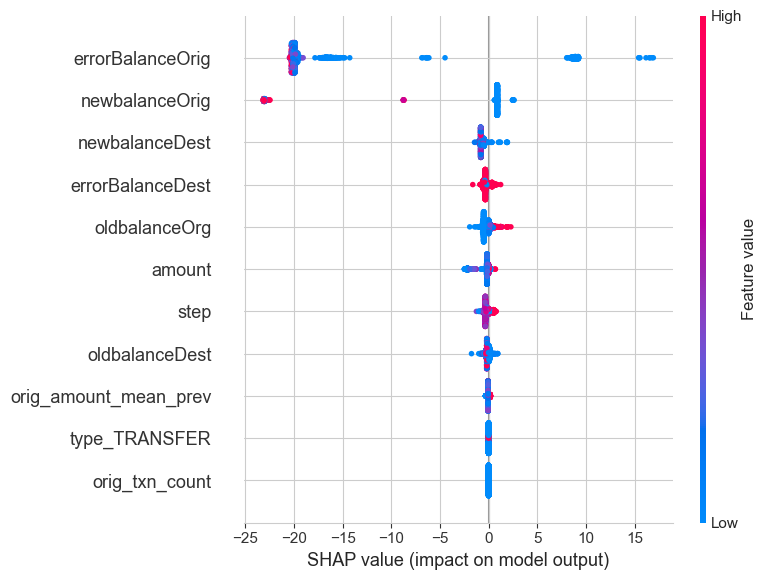

In [39]:
shap.summary_plot(shap_values, X_shap, feature_names=feat_cols, show=True)

In [41]:
proba_shap = lgbm_explain.predict_proba(X_shap)[:, 1]

fraud_candidates = np.where((y_shap == 1) & (proba_shap > 0.8))[0]
legit_candidates = np.where((y_shap == 0) & (proba_shap < 0.1))[0]

def explain_row(i, title):
    print(f"\n {title} (row {i}): true={y_shap[i]}, proba={proba_shap[i]:.3f} ")
    contrib = pd.DataFrame({
        'feature': feat_cols,
        'value': X_shap[i],
        'shap_contribution': shap_values[i],
    }).sort_values('shap_contribution', key=lambda s: s.abs(), ascending=False)
    print(contrib.to_string(index=False))

if len(fraud_candidates):
    explain_row(fraud_candidates[0], 'Confident FRAUD prediction')
if len(legit_candidates):
    explain_row(legit_candidates[0], 'Confident LEGITIMATE prediction')


 Confident FRAUD prediction (row 55): true=1, proba=1.000 
              feature      value  shap_contribution
     errorBalanceOrig       0.00          15.549295
       newbalanceOrig       0.00           2.455968
       newbalanceDest       0.00           1.053474
        oldbalanceOrg 2308798.25           0.937362
     errorBalanceDest 2308798.25           0.751536
                 step     223.00          -0.294720
orig_amount_mean_prev 2308798.25           0.155780
       oldbalanceDest       0.00           0.149873
               amount 2308798.25           0.079695
        type_TRANSFER       1.00          -0.000004
       orig_txn_count       1.00           0.000000

 Confident LEGITIMATE prediction (row 0): true=0, proba=0.000 
              feature         value  shap_contribution
     errorBalanceOrig 109874.976562      -1.991230e+01
       newbalanceOrig      0.000000       8.807079e-01
        oldbalanceOrg      0.000000      -6.758170e-01
     errorBalanceDest      0.010

## 9. Contributions, Originality, and Attribution

### 9.1 Group member contributions

*Update this section before submission. The template below is a starting point.*

| Member | Code | Writing | Video |
|---|---|---|---|
| **Hermann Tankeu** | Data loading, EDA, feature engineering, leakage-free pipeline, model training, ) | writing to explain code | Sections 6-9 of video |
| **Sivaragha Deepika Buddana**| Polishing and expanding the code explainations, and proof-reading the entire report | Wrote explanations for the EDA, baseline comparison, limitations, future work, originality, attribution, and conclusion sections. Proofread the full report for clarity, captions, formatting, and consistency. | Helped prepare the written talking points for the video and handled final organization/submission materials, including repository upload checks, explained sections 1-5 in the video



### 9.2 Originality — how our work extends Kaggle/GitHub

| Contribution | Present in elangovana? | Present in mtalaltariq? | Present in ours? |
|---|---|---|---|
| AUCPR as primary metric | ✓ | ✗ | ✓ |
| SMOTE oversampling | ✗ | ✗ | ✓ |
| **SMOTE strictly inside CV folds (leakage-free)** | n/a | n/a | **✓** |
| Balance-error features | partial | ✗ | ✓ |
| **Per-originator velocity features** | ✗ | ✗ | **✓** |
| XGBoost | ✓ | ✗ | ✓ |
| LightGBM | ✗ | ✗ | ✓ |
| **Stacking ensemble** | ✗ | ✗ | **✓** |
| **Cost-sensitive threshold tuning** | ✗ | ✗ | **✓** |
| **SHAP interpretability (global + local)** | ✗ | ✗ | **✓** |

### 9.3 Attributions

- **Dataset**: Lopez-Rojas, Elmir & Axelsson, *PaySim: A financial mobile money
  simulator for fraud detection*, EMSS 2016. Kaggle mirror: `ealaxi/paysim1`.
- **Prior notebooks compared against**:
  - elangovana, *PaySim Synthetic Dataset Fraud Detection* (GitHub).
  - mtalaltariq, *Fraud Detection using PaySim Dataset (LR, RF)* (Kaggle).
- **Libraries**: scikit-learn, imbalanced-learn (SMOTE), XGBoost, LightGBM,
  SHAP, pandas, numpy, matplotlib, seaborn.

### 9.4 Limitations and future work

- **Synthetic data** PaySim is simulator-generated; real-world fraud signatures
  differ. Actual financial fruad can include more complicated details like customer histories, merchant relationships, locations, device information and other behaviors. Before we can use this model in a real life setting, we would need to validate it on real life institution specific data with stronger privacy and compliance controls.
   
- **Temporal validation** We use a random stratified split. A time-based split
  (train on `step < T`, test on `step ≥ T`) would better match the production
  scenario and is a natural next step. Real fruad detection systems, however, would usually predict future acivity based on pat activity. A stronger future model would use a time-based split. For example, we could train on earlier transaction steps and test on the later steps. This would give us a better model to use in production and better measure how well the model generalizes future fraud patterns.

  
- **Cost model** Our two cost assumptions are illustrative assumptions for false negatives and false positives. In a real banking enviornment model, the cost of missing fraud includes things such as direct financial loss, customer harm and regulatory risk. The cost of a false alarm could be customer inconvenience and manual review which takes time and energy from other tasks. A production version of this model should use actual cost estimates instead of assumptions to ensure accuracy. 

  
- **Concept drift** Fraud patterns change overtime as people adapt to the detection systems. A model that performs well for a few years may not perform as well in the years to come. A future model should take into account drift monitoring, scheduled retraining and alerts when model performance begins to change. This would make the model more realisitic for long term use. 

- **Alternative resampling methods** This project uses SMOTE to address class imbalance, but other resampling strategies could be more beneficial and allow the model to perform better. Experimenting with different sampling methods can help determine whether synthetic minority examples or cost-aware model training provide the best fraud recall without giving us too many false positives.


### 9.5 Conclusion

We presented a leakage-free, cost-sensitive, and interpretable fraud detection
pipeline for PaySim that extends the best public notebooks along four
dimensions: correctness of the resampling protocol, richness of engineered
features, alignment of evaluation with business cost, and per-prediction
explainability. All five models we trained were evaluated on a common
held-out test set with the same metrics, providing a fair internal comparison
and a transparent reference point for future work on this dataset.